# **필요한 라이브러리 불러오기**

In [ ]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
# device : gpu를 사용할 경우에는 'cuda', 그렇지 않을 경우에는 'cpu'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# 랜덤 시드 고정
# 실험 조건을 동일하게 설정하여 같은 input을 넣으면 같은 결과가 나올 수 있도록 함
random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

# **Hyper parameter**

## ✏️ TODO: Hyperparameter 설정하기

모델 학습에 사용할 Hyperparameter를 직접 작성하세요.

- `batch_size`: 한 번에 학습할 데이터 개수
- `epochs`: 전체 학습 데이터의 반복 횟수
- `learning_rate`: 모델의 가중치를 조정하는 정도
- `num_classes`: 분류할 전체 클래스 수

In [ ]:
# Hyperparameter 설정
batch_size = ____       # 배치크기
epochs = ____           # 학습 횟수
learning_rate = ____    # 학습률
num_classes = ____      # 총 클래스 수

# **CIFAR10 데이터셋 불러오기**
- 50,000개의 train data, 10,000개의 test data
- classes = { 0 : airplane, 1 : automobile, 2 : bird, 3 : cat, 4 : deer, 5 : dog, 6 : frog, 7 : horse, 8 : ship, 9 : truck }

In [ ]:
train_dataset = datasets.CIFAR10(root='dataset/', train=True, download=True,
                                 transform=transforms.ToTensor())
test_dataset = datasets.CIFAR10(root='dataset/', train=False, download=True,
                                transform=transforms.ToTensor())

train_loader=torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 170498071/170498071 [00:13<00:00, 12723092.29it/s]


Extracting dataset/cifar-10-python.tar.gz to dataset/
Files already downloaded and verified


In [ ]:
# train data 정보 확인
train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: dataset/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
# test data 정보 확인
test_dataset

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: dataset/
    Split: Test
    StandardTransform
Transform: ToTensor()

# **데이터 시각화**

In [ ]:
# 이미지 레이블을 실제 이름과 매치
classes = {0:'airplane', 1:'automobile', 2:'bird', 3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

In [ ]:
# train data의 첫번째 샘플을 출력
train_dataset[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

* 이미지에 해당하는 텐서와, 레이블로 이루어져 있음.
* 마지막의 6은 위 CLASSES 딕셔너리를 보면 frog에 해당.

In [ ]:
# 첫번째 데이터 묶음 반환
images, labels = next(iter(train_loader))

In [ ]:
# 데이터 shape 확인
images.shape , labels.shape

(torch.Size([128, 3, 32, 32]), torch.Size([128]))

In [ ]:
def minmax_scale(input): # 픽셀 값 범위 0 ~ 1로 조정
  min_val = np.min(input) # input의 최소값
  max_val=np.max(input) # input의 최대값
  out = (input-min_val)/(max_val-min_val)
  return out

img = images.numpy().transpose(0,2,3,1) # (128,3,32,32) -> (128,32,32,3) 채널을 가장 마지막 순서로
img = minmax_scale(img) # 이미지의 픽셀 값을 0과 1사이의 값으로 조정
label = labels.numpy() # label: tensor -> numpy

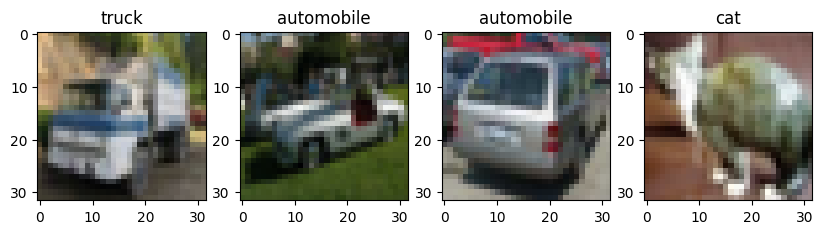

In [ ]:
# train data의 이미지와 레이블을 시각화

plt.figure(figsize=(10,20)) # 10x20 사이즈의 figure

plt.subplot(1,4,1) # 1 행 4열 중 첫번째
plt.imshow(img[0]) # batch 중 첫번째 이미지 출력
plt.title(classes[label[0]]) # batch 중 첫번째 라벨 출력

plt.subplot(1,4,2) # 1 행 4열 중 두번째
plt.imshow(img[1]) # batch 중 두번째 이미지 출력
plt.title(classes[label[1]]) # batch 중 두번째 라벨 출력

plt.subplot(1,4,3) # 1 행 4열 중 세번째
plt.imshow(img[2]) # batch 중 세번째 이미지 출력
plt.title(classes[label[2]]) # batch 중 세번째 라벨 출력

plt.subplot(1,4,4) # 1 행 4열 중 네번째
plt.imshow(img[3]) # batch 중 네번째 이미지 출력
plt.title(classes[label[3]]) # batch 중 네번째 라벨 출력

plt.show() # figure 표시

# **모델 설계**
- CNN

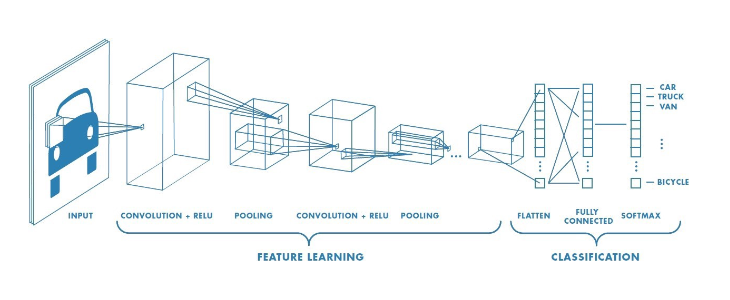

## ✏️ TODO: Batch Normalization 적용하기

각 Convolution Layer에 Batch Normalization을 적용하세요.

- `nn.BatchNorm2d()`를 사용합니다.
- 각 `Conv2d`의 출력 채널 수와 동일한 값을 작성합니다.
- `Conv2d`와 `ReLU` 사이에 Batch Normalization을 추가하세요.
- 총 3개의 Convolution Block에 각각 한 줄씩 작성하세요.

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Conv Layer block 1
        # input shape = (batch, 3, 32, 32)
        #   Conv     -> (batch, 16, 32, 32)
        #   Pool     -> (batch, 16, 16, 16)
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),

            # Batch Normalization을 작성하세요.


            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))

        # Conv Layer block 2
        # input shape = (batch, 16, 16, 16)
        #   Conv     -> (batch, 32, 16, 16)
        #   Pool     -> (batch, 32, 8, 8)
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),

            # Batch Normalization을 작성하세요.


            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))

        # Conv Layer block 3
        # input shape = (batch, 32, 8, 8)
        #   Conv     -> (batch, 64, 8, 8)
        self.layer3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),

            # Batch Normalization을 작성하세요.


            nn.ReLU(inplace=True))

        # Dense Layer block 4
        # 64x8x8 inputs -> 1024 outputs
        self.fc1 = nn.Sequential(
            nn.Linear(64*8*8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1))

        # Dense Layer block 5
        # 1024 inputs -> 10 outputs
        self.fc2 = nn.Sequential(nn.Linear(1024, 10))

    # Inference (input data를 네트워크에 순방향으로 전달하여 출력으로 변환)
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1) # flatten all dimensions except batch
        x = self.fc1(x)
        x = self.fc2(x)
        return x

# CNN 모델 선언
model = CNN().to(device)
# 모델 구성 출력
print(model)

CNN(
  (layer1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (fc1): Sequential(
    (0): Linear(in_features=4096, out_features=1024, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.1, inplace=False)
  )
  (fc2): Seq

# **Train**

In [ ]:
# cost function과 optimizer 정의
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# 모델 학습
# epoch마다 train loss 기록
loss_list = []
model.train()

for epoch in range(epochs):
  avg_loss = 0.0
  total_loss = 0.0
  for iter, data in enumerate(train_loader):
    images, labels = data
    images, labels = images.to(device), labels.to(device)

    # initialize weights
    optimizer.zero_grad()

    # forward
    outputs = model(images)

    # loss 계산
    loss = criterion(outputs, labels)

    # update parameters
    loss.backward()
    optimizer.step()

    # loss 값 기록
    avg_loss += loss.item()
    total_loss += loss.item()

    # 케이스 100개 마다 평균 loss 값 출력
    if epoch == 0 and iter==0:
      loss_list.append(total_loss)

    if (iter+1) % 100==0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.5f}'.format(
      epoch, iter+1, len(train_loader), avg_loss/100.))
      # 누적 loss 값 초기화
      avg_loss = 0.0
  # epoch 마다 평균 loss 값 loss_list에 추가
  loss_list.append(total_loss/(iter+1))
print('\nLearning finished!')

Train Epoch: 0 [100/391]	Loss: 1.97544
Train Epoch: 0 [200/391]	Loss: 1.63922
Train Epoch: 0 [300/391]	Loss: 1.49646
Train Epoch: 1 [100/391]	Loss: 1.35375
Train Epoch: 1 [200/391]	Loss: 1.30279
Train Epoch: 1 [300/391]	Loss: 1.24900
Train Epoch: 2 [100/391]	Loss: 1.16817
Train Epoch: 2 [200/391]	Loss: 1.13120
Train Epoch: 2 [300/391]	Loss: 1.10776
Train Epoch: 3 [100/391]	Loss: 1.02620
Train Epoch: 3 [200/391]	Loss: 1.03378
Train Epoch: 3 [300/391]	Loss: 1.00106
Train Epoch: 4 [100/391]	Loss: 0.95508
Train Epoch: 4 [200/391]	Loss: 0.93309
Train Epoch: 4 [300/391]	Loss: 0.93365
Train Epoch: 5 [100/391]	Loss: 0.88634
Train Epoch: 5 [200/391]	Loss: 0.87200
Train Epoch: 5 [300/391]	Loss: 0.87819
Train Epoch: 6 [100/391]	Loss: 0.82482
Train Epoch: 6 [200/391]	Loss: 0.82689
Train Epoch: 6 [300/391]	Loss: 0.81254
Train Epoch: 7 [100/391]	Loss: 0.77556
Train Epoch: 7 [200/391]	Loss: 0.78729
Train Epoch: 7 [300/391]	Loss: 0.77896
Train Epoch: 8 [100/391]	Loss: 0.74045
Train Epoch: 8 [200/391]	

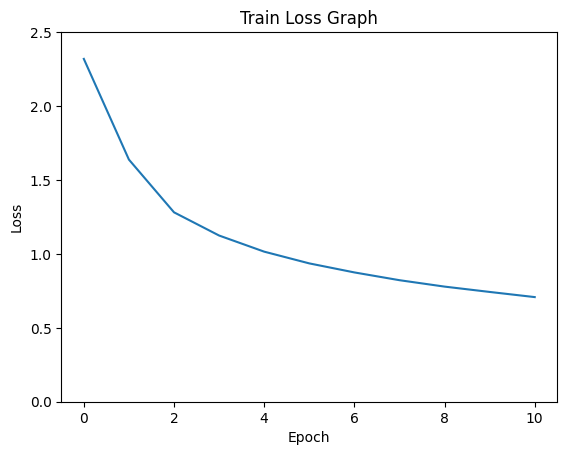

In [ ]:
# Loss graph
plt.plot(range(0,epochs+1), loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
# y축의 값이 0과 2.5 사이의 값이 되도록
plt.ylim(0,2.5)
# 그래프 제목 설정
plt.title('Train Loss Graph')
plt.show()

# **Test**

Accuracy : 64.96%
Label:  deer
Prediction:  deer


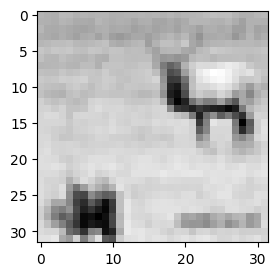

In [ ]:
# 모델 성능 확인
with torch.no_grad(): # torch.no_grad(): gradient 계산을 수행하지 않음
  model.eval()
  accuracy = 0.0
  for iter, data in enumerate(test_loader):
    images, labels = data
    images = images.to(device)
    labels = labels.to(device)
    output = model(images)

    # 모델이 예측한 값과 실제 레이블인 labels를 비교
    # argmax 함수를 이용해 예측한 값 중 가장 확률이 높은 값을 예측 값으로 사용 (예) [0.1,0.05,0.7,0,0,0.15] -> 2
    pred = torch.argmax(output,1) == labels
    accuracy += pred.float().sum()

  print("Accuracy : {:.2f}%".format(100*accuracy/len(test_dataset)))

  # 테스트 데이터에서 무작위로 하나를 뽑아서 예측

  # 0과 검증용 데이터셋 크기 사이의 랜덤한 숫자 r에 저장
  r = random.randint(0, len(test_dataset) - 1)

  # r번째 이미지 데이터의 크기를 [3, 32, 32] -> [1, 3, 32, 32]로 변경
  X_single_data = test_dataset[r][0].unsqueeze(0).float().to(device)
  Y_single_data = test_dataset[r][1]

  # 모델 예측 예시 출력
  print('Label: ', classes[Y_single_data])
  single_prediction = model(X_single_data)
  print('Prediction: ', classes[torch.argmax(single_prediction, 1).item()])

  # 시각화
  img = test_dataset[r][0].unsqueeze(0).numpy().transpose(0,2,3,1)
  img = minmax_scale(img)
  plt.figure(figsize=(3,3))
  plt.imshow(img[0])
  plt.show()

# **모델 저장**

In [ ]:
# 모델의 weight만 저장
torch.save(model.state_dict(),'cnn_cifar10_weight.pth')

In [ ]:
# 모델 통째로 저장
torch.save(model,'cnn_cifar10.pth')